# HistoMap Tutorial: Mapping Annotations to Xenium Data

## Introduction

This tutorial demonstrates how to use the HistoMap package to map histological annotations from QuPath onto Xenium cells and generate an annotation map for downstream analysis.

### Why Use HistoMap with Xenium?

Xenium provides single-cell resolution in situ gene expression, with each cell already delineated by a segmentation boundary. HistoMap lets you:

1. Import tissue annotations from pathology tools like QuPath
2. Compute, for every segmented cell, what percentage of its area overlaps each annotation region
3. Integrate histological context with the Xenium gene expression matrix
4. Perform region-specific analyses (differential expression, spatial statistics, etc.)

### How Xenium differs from Visium / Visium HD here

Visium and Visium HD analyze fixed-size spots/bins; the "unit" HistoMap overlaps against annotations is a synthetic disk (Visium) or a square bin (Visium HD). For Xenium, that unit is the **cell segmentation polygon itself** (`cell_boundaries`), so overlap percentages reflect how much of each individual cell's shape sits inside an annotated region.

> **Note:** Xenium SpatialData objects typically expose more than one Shapes element (e.g. both `cell_boundaries` and `nucleus_boundaries`), only one of which lines up with the expression table. HistoMap matches the correct one automatically by comparing indices, but you should always create Xenium HistoMap objects with `visium_type='xenium'` set explicitly — auto-detection is tuned for Visium/Visium HD and can misclassify Xenium data (its cell counts and polygon geometries look similar to a Visium HD bin grid).

## Tutorial Overview

In this tutorial, we will:

1. Load Xenium data and create a HistoMap object with histological annotations
2. Visualize annotations and compute per-cell overlaps
3. Generate a comprehensive annotation map
4. Export the annotated data for downstream analysis

Let's begin!

## 1. Setting up the Environment

First, let's import the necessary libraries and configure our environment.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Import required libraries
import spatialdata          # For handling spatial data objects
import spatialdata_io       # For reading spatial data formats
import histomaptx as hm     # Main package for annotation integration
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [12, 10]


## 2. Creating the HistoMap Object

We need three key inputs to create a HistoMap object:

| Input | Description |
|-------|-------------|
| `visium_path` | Path to the Xenium output folder (`*_outs`) |
| `annotation_file` | Histological annotation GeoJSON exported from QuPath |
| `full_res_image` | Full-resolution image used for annotation (typically Xenium's combined `morphology.ome.tif`) |

### 2.1 Set Paths

In [2]:
# Path to your Xenium dataset folder (the SpaceRanger/Xenium Analyzer *_outs folder)
visium_path = "/home/croizer/Downloads/Xenium_V1_Human_Kidney_FFPE_Protein_updated_outs"

# Path to QuPath annotation GeoJSON file
annotation_file = "/home/croizer/Documents/03_Paper/05_Histomap/Xenium/annotation_bcells.geojson.gz"

# Path to the full-resolution image used for annotation in QuPath.
# Xenium writes a combined multi-channel image at the top level of the output folder
# (morphology.ome.tif) as well as per-channel images under morphology_focus/ - use whichever
# one your QuPath annotations were actually drawn on.
full_res_image = f"{visium_path}/morphology.ome.tif"


In [3]:
# Load the Xenium data using spatialdata_io
sdata = spatialdata_io.xenium(visium_path)
print(sdata)


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (35, 27328, 54002), (35, 13664, 27001), (35, 6832, 13500), (35, 3416, 6750), (35, 1708, 3375)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (27328, 54002), (13664, 27001), (6832, 13500), (3416, 6750), (1708, 3375)
│     └── 'nucleus_labels': DataTree[yx] (27328, 54002), (13664, 27001), (6832, 13500), (3416, 6750), (1708, 3375)
├── Points
│     └── 'transcripts': DataFrame with shape: (847626296, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (465534, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (471228, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (465534, 405)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)


### 2.2 Create the HistoMap Object

> **Reminder:** always pass `visium_type='xenium'` explicitly for Xenium data (see the note in the introduction above).

In [4]:
# Create a HistoMap object by combining the annotation file, Xenium data, and the full resolution image
histomap = hm.HistoMap(annotation_file, sdata, full_res_image, visium_type='xenium')

# Display information about the HistoMap object
print(histomap)


HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Documents/03_Paper/05_Histomap/Xenium/annotation_bcells.geojson.gz
📂 Full resolution image used: /home/croizer/Downloads/Xenium_V1_Human_Kidney_FFPE_Protein_updated_outs/morphology.ome.tif
🔢 Number of annotations present: 1
🏷 Annotations: Bcells
🏷 Activated annotations: Bcells
🏷 Disabled annotations: 

-------Spatial Data--------
Type is xenium

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (35, 27328, 54002), (35, 13664, 27001), (35, 6832, 13500), (35, 3416, 6750), (35, 1708, 3375)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (27328, 54002), (13664, 27001), (6832, 13500), (3416, 6750), (1708, 3375)
│     └── 'nucleus_labels': DataTree[yx] (27328, 54002), (13664, 27001), (6832, 13500), (3416, 6750), (1708, 3375)
├── Points
│     └── 'transcripts': DataFrame with shape: (847626296, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (465534, 1) (2D sh

### 2.3 Visualize Annotations

Before computing overlaps, let's visualize the annotations to confirm they are correctly aligned with the tissue image.

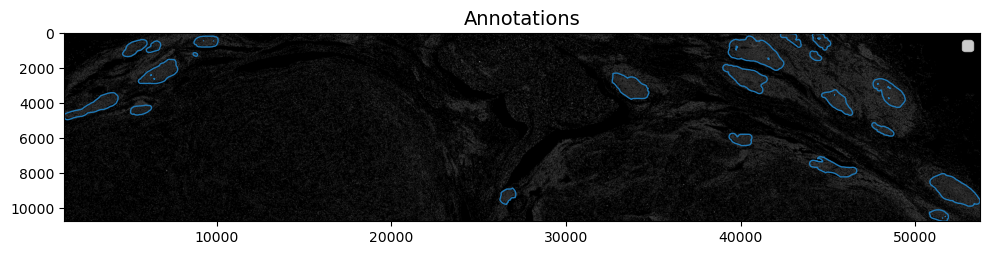

In [5]:
hm.plot_annotations(histomap, display_image=True)


## 3. Computing Annotation Overlaps

A key feature of HistoMap is the ability to quantify how much each Xenium cell overlaps with each annotation region - a continuous measure of annotation coverage per cell (0 to 100%), computed directly from the `cell_boundaries` segmentation polygons.

In [ ]:
histomap.compute_annotation_overlap('all')


Starting calculating overlap
1/1 layer processed: Bcells
Intersecting spots: 24056
Updated 'Annotation_positive' for 'Bcells' with threshold 50%.
Computed annotation overlap for: Bcells. Updated Overlay status.


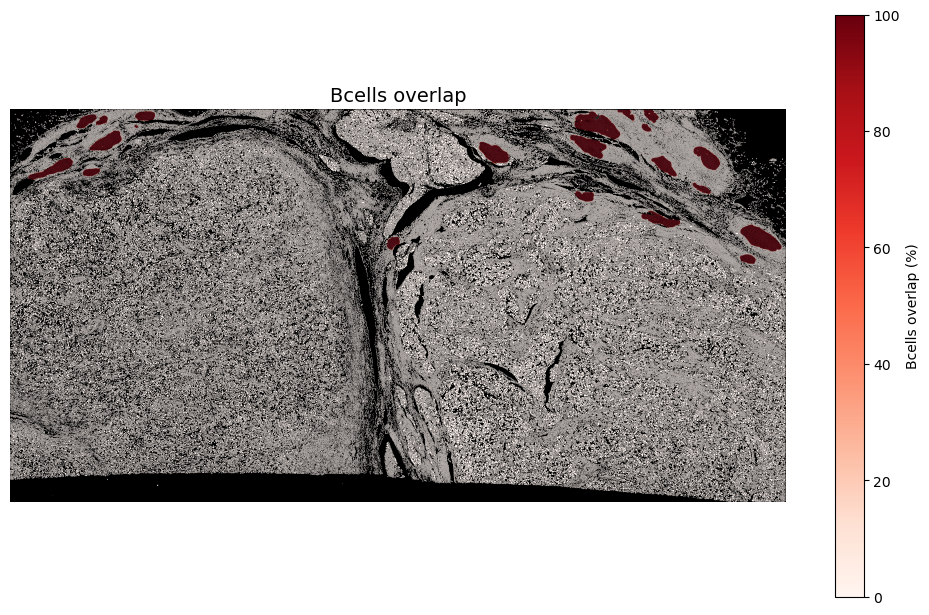

In [7]:
# Visualize the per-cell overlap percentage for a specific annotation as a heatmap.
# For visium_type='xenium', this renders through a generic matplotlib/geopandas fallback
# (no spatialdata_plot rendering path exists for Xenium's cell-boundary polygons).
hm.plot_annotation_overlay(histomap, annotation='Bcells', cmap='Reds')


In [9]:
# Generate the final annotation map: each cell is assigned to a single annotation
# based on overlap percentage and priority order.
histomap.generate_annotation_map()


Annotating remaining spots with the most overlapping annotation...
Annotation map successfully generated


In [ ]:
histomap.change_annotation_color({'Bcells': 'Red'})

Updated color for 'Bcells' to 'Red'


False

In [ ]:
# Plot the final annotation map on the tissue section
hm.plot_annotation_map(histomap, display_image=True)


## 5. Exporting for Downstream Analysis

`to_anndata()` merges every column computed above (`*_overlap`, `*_positive`, `Annotation_map`) directly into `adata.obs`, aligned by cell (`spot_id`), giving you a single AnnData object ready for standard Scanpy analysis.

In [11]:
adata = histomap.to_anndata()
print(adata)
adata.obs['Annotation_map'].value_counts()


AnnData object with n_obs × n_vars = 465534 × 405
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'spot_id', 'Bcells_overlap', 'Bcells_positive', 'Annotation_map'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


Annotation_map
None      441492
Bcells     24042
Name: count, dtype: int64

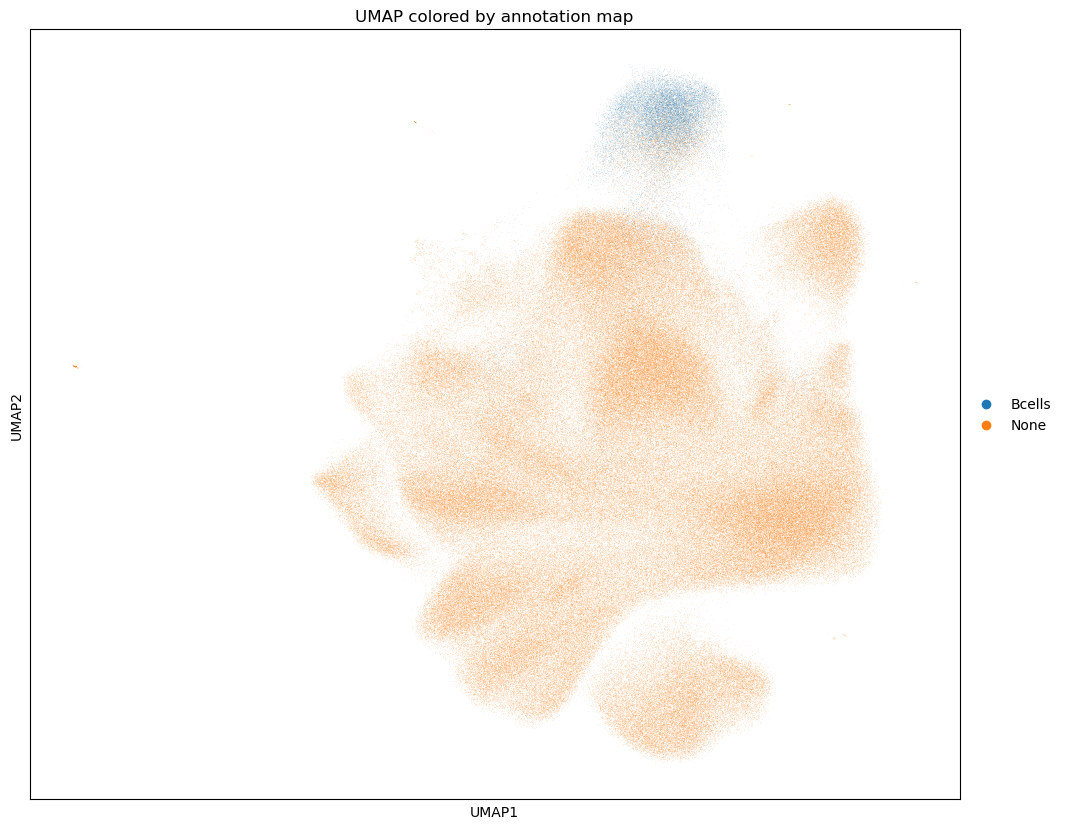

In [12]:
import scanpy as sc

# Standard Scanpy preprocessing pipeline
sc.pp.filter_cells(adata, min_counts=1)
sc.pp.filter_genes(adata, min_counts=1)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(adata, color='Annotation_map', title="UMAP colored by annotation map")


        names      scores  logfoldchanges          pvals      pvals_adj
0       MS4A1  212.655746        6.176929   0.000000e+00   0.000000e+00
1       CXCR4  155.077362        2.682467   0.000000e+00   0.000000e+00
2       CD79A  147.830048        4.531564   0.000000e+00   0.000000e+00
3       BANK1  142.774139        5.016461   0.000000e+00   0.000000e+00
4        IRF8   98.627556        3.219661   0.000000e+00   0.000000e+00
5       PTPRC   95.748108        1.357453   0.000000e+00   0.000000e+00
6     HLA-DRA   93.762207        0.981897   0.000000e+00   0.000000e+00
7        CD19   91.540962        5.022668   0.000000e+00   0.000000e+00
8        SELL   72.314377        2.390913   0.000000e+00   0.000000e+00
9       PLCG2   65.409607        2.706376   0.000000e+00   0.000000e+00
10       CD83   56.734802        3.193351   0.000000e+00   0.000000e+00
11      TCL1A   54.412750        4.486650   0.000000e+00   0.000000e+00
12       CD69   52.792156        2.123816   0.000000e+00   0.000

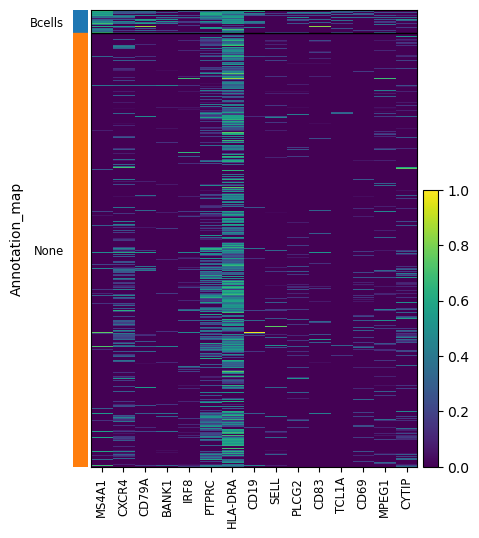

In [ ]:
import scanpy as sc

adata.obs['Annotation_map'] = adata.obs['Annotation_map'].astype('category')

# Bcells vs. None
sc.tl.rank_genes_groups(
    adata, groupby='Annotation_map',
    groups=['Bcells'], reference='None',
    method='wilcoxon',
)

de_df = sc.get.rank_genes_groups_df(adata, group='Bcells')

top_genes = de_df.head(15)['names'].tolist()


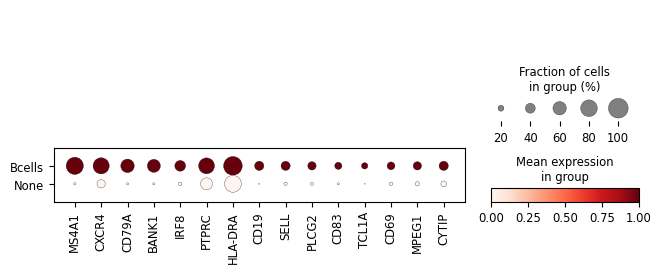

In [15]:
sc.pl.dotplot(adata, var_names=top_genes, groupby='Annotation_map', standard_scale='var')


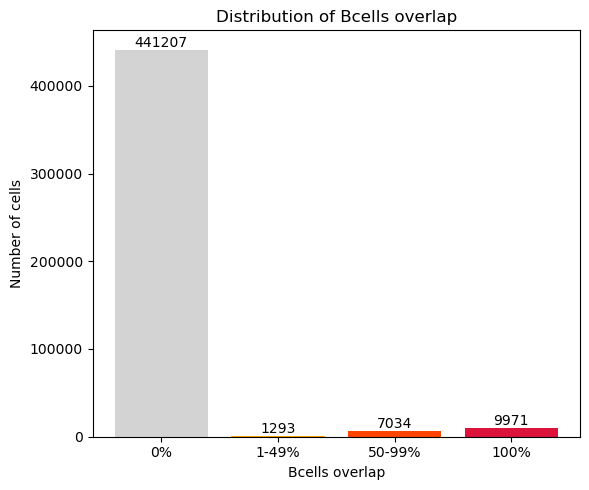

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
overlap = adata.obs['Bcells_overlap']

overlap = adata.obs['Bcells_overlap']

categories = pd.Series(
    np.select(
        [overlap == 0, (overlap > 0) & (overlap < 50), (overlap >= 50) & (overlap < 100), overlap == 100],
        ['0%', '1-49%', '50-99%', '100%'],
        default='other',
    ),
    index=adata.obs.index,
)
counts = categories.value_counts().reindex(['0%', '1-49%', '50-99%', '100%'])

plt.figure(figsize=(6, 5))
bars = plt.bar(counts.index, counts.values, color=['lightgrey', 'orange', 'orangered', 'crimson'])
plt.ylabel('Number of cells')
plt.xlabel('Bcells overlap')
plt.title('Distribution of Bcells overlap')
for bar, v in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()



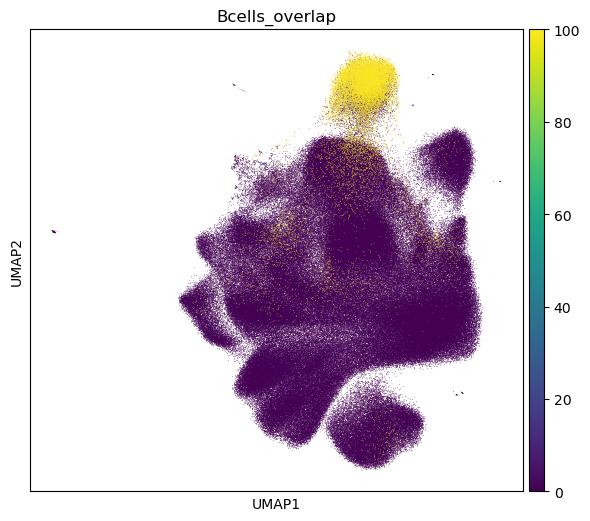

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
sc.pl.umap(adata, color='Bcells_overlap', s=1,  ax=ax, show=True)

In [ ]:
# Save the annotated AnnData object to disk for later reuse
adata.write_h5ad('/home/croizer/Documents/03_Paper/05_Histomap/Xenium/annotated_xenium.h5ad')
